This step loads the dataset and displays the first few rows 
to understand the structure and variables present in the data.

In [7]:
import pandas as pd

# Load dataset
df = pd.read_csv("insurance.csv")

# Preview data
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


This shows the data types and confirms whether there are any missing values. All columns should have 1338 non-null values, indicating no missing data.

In [9]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


This provides summary statistics such as mean, min, and max.
It helps identify potential outliers, especially in the 'charges' column.

In [10]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

This confirms that there are no missing values in the dataset,
meaning no data cleaning for null values is required.

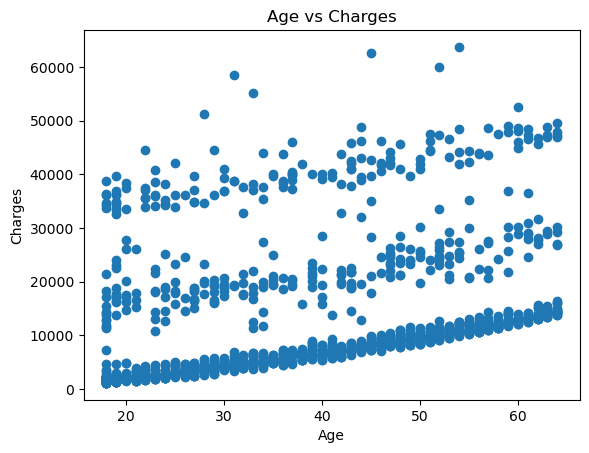

In [11]:
import matplotlib.pyplot as plt

plt.scatter(df['age'], df['charges'])
plt.xlabel('Age')
plt.ylabel('Charges')
plt.title('Age vs Charges')
plt.show()

This scatter plot helps visualize the relationship between age and medical charges.
A positive trend suggests that charges increase with age.

In [12]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


Categorical variables (sex, smoker, region) are converted into numerical formulas using one-hot encoding so that they can be used in the regression model.

In [13]:
X = df.drop('charges', axis=1)
y = df['charges']

X contains the independent variables (features)
y contains the dependent variable (target) which is 'charges'

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

The dataset is split into training (80%) and testing (20%) sets.
This ensures the model is evaluated on unseen data.

In [29]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

A linear regression model is trained using the training data.
The model learns the relationship between features and medical charges.

In [20]:
y_pred = model.predict(X_test)

The trained model is used to predict medical charges on the test dataset.

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 4181.1944737536505
MSE: 33596915.85136146
R2 Score: 0.7835929767120723


MAE measures average prediction error
MSE penalizes larger errors
R2 score indicates how well the model explains variance in the data

In [22]:
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
coefficients

,Coefficient
age,256.975706
bmi,337.092552
children,425.278784
sex_male,-18.591692
smoker_yes,23651.128856
region_northwest,-370.677326
region_southeast,-657.864297
region_southwest,-809.799354


This shows the impact of each feature on medical charges.
For example, 'smoker_yes' is expected to have a strong positive coefficient,
indicating that smokers have significantly higher charges.

The model demonstrates that smoking status is the most significant predictor of medical charges. While the model performs reasonably well, its accuracy may be affected by outliers and the assumption of linear relationships. Further improvements could include feature transformation or using more complex models.

To evaluate the performance of the linear regression model, three metrics were used: Mean Absolute Error (MAE), Mean Squared Error (MSE), and R² score.

MAE was used to measure the average magnitude of prediction errors in a simple and interpretable way. MSE was used to penalize larger errors more heavily, making it useful for identifying significant deviations. The R² score was used to determine how well the model explains the variance in the target variable, making it a key indicator of overall model performance

The model achieved an R² score of 0.7836, indicating that approximately 78.36% of the variability in medical insurance charges is explained by the model. This suggests that the model has strong predictive capability.

The MAE value indicates the average difference between predicted and actual charges, showing how far predictions deviate from real values. The MSE further highlights that larger errors exist, as it penalizes larger deviations more heavily

Overall, the model can be considered successful as it captures a large proportion of the variation in the data. The relatively high R² score indicates a strong relationship between the selected features and the target variable.

However, the model is not perfect, as some variation remains unexplained. This suggests that additional variables or more complex relationships may exist in the data.

One limitation of the model is the assumption of linearity, which may not fully capture the relationships between variables such as BMI and charges. Additionally, the presence of outliers in the dataset may negatively impact the model’s performance. The model may also be affected by unobserved variables not included in the dataset.

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

from sklearn.linear_model import LinearRegression
model_scaled = LinearRegression()
model_scaled.fit(X_train, y_train)

y_pred_scaled = model_scaled.predict(X_test)

from sklearn.metrics import r2_score
print("New R2 Score:", r2_score(y_test, y_pred_scaled))

New R2 Score: 0.7835929767120723


Feature scaling was applied to standardize the data.

In [25]:
import numpy as np

y_log = np.log(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

model_log = LinearRegression()
model_log.fit(X_train, y_train)

y_pred_log = model_log.predict(X_test)

from sklearn.metrics import r2_score
print("Log Model R2:", r2_score(y_test, y_pred_log))

Log Model R2: 0.8047311493462987


A log transformation is applied to the target variable to reduce skewness and minimize the effect of extreme values (outliers) in charges.

After evaluating the model, it can be concluded that the linear regression model performs well, with a strong R² score indicating good predictive capability. However, improvements such as feature scaling and transformation of the target variable can further enhance performance. This demonstrates that while the model is effective, there is room for optimization